## Flagging vector invoice for manual review 


In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect(r"C:\Users\User\Desktop\ML project\Data\inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print("table_name ",table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)
    

table_name  purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table_name  purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table_name  vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table_name  begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table_name  end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df =pd.read_sql_query("""select
                  p.PONumber,
                  count(distinct p.Brand) as total_brand,
                  sum(p.Quantity) as total_item_quantity,
                  sum(p.Dollars) as total_item_dollars,
                  avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
                  from purchases p
                  group by p.PONumber""",conn)

In [6]:
purchase_agg_df

,PONumber,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [7]:
pd.read_sql_query("""
select
vi.Quantity as invioce_quantity,
vi.Dollars as invoice_dollar,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay
from vendor_invoice vi
""",conn)

,invioce_quantity,invoice_dollar,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [8]:
df =pd.read_sql_query("""
WITH purchase_agg_df as(
select
p.PONumber,
count(distinct p.Brand) as total_brand,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
)
select
vi.Quantity as invioce_quantity,
vi.Dollars as invoice_dollar,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
pa.total_brand,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay
from vendor_invoice vi
left join purchase_agg_df pa
on vi.PONumber = pa.PONumber""",conn)

In [9]:
df

,invioce_quantity,invoice_dollar,Freight,days_po_to_invoice,days_to_pay,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay
0,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [10]:
df.isnull().sum()

invioce_quantity       0
invoice_dollar         0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brand            0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [11]:
df.dtypes

invioce_quantity         int64
invoice_dollar         float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brand              int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [12]:
def create_invoice_rsk(row):
    if (abs(row["invoice_dollar"] - row["total_item_dollars"])>5):
        return 1

    if row["avg_receiving_delay"]>10:
        return 1
    else:
        return 0

df["flag_invoice"] = df.apply(create_invoice_rsk,axis = 1)
df["flag_invoice"].value_counts()
    

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

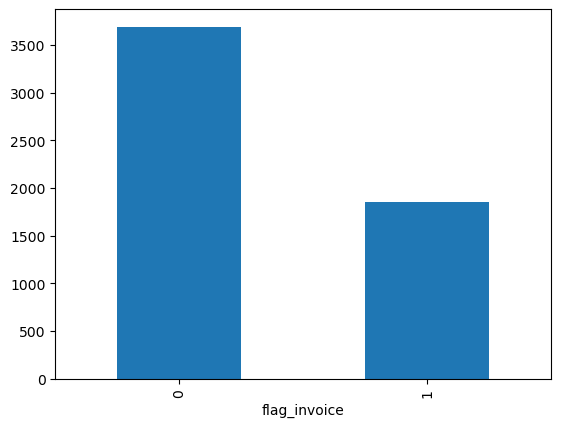

In [13]:
df["flag_invoice"].value_counts().plot(kind = "bar")

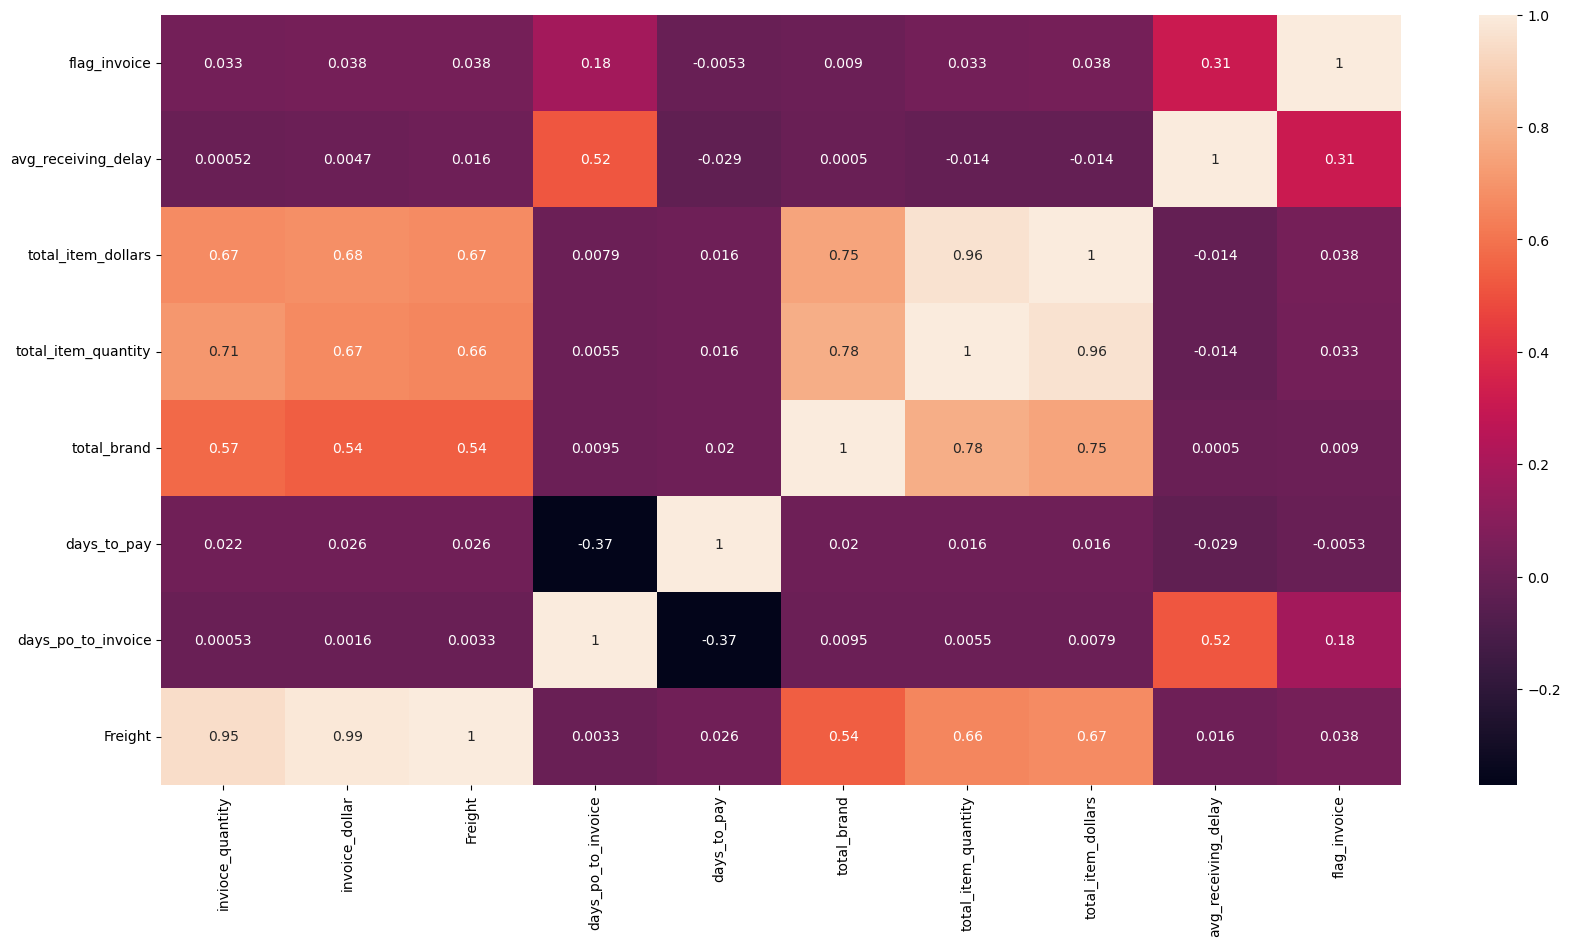

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize = (20,10))
sns.heatmap(df.corr().iloc[:1:-1],annot=True,
    fmt='.2g')
plt.show()

In [15]:
flagged = df[df["flag_invoice"] ==1]
normal = df[df["flag_invoice"] ==0]

In [16]:
significant = []
nonsignificant = []
result = []


In [17]:
df.columns

Index(['invioce_quantity', 'invoice_dollar', 'Freight', 'days_po_to_invoice',
       'days_to_pay', 'total_brand', 'total_item_quantity',
       'total_item_dollars', 'avg_receiving_delay', 'flag_invoice'],
      dtype='object')

In [19]:
features = ['invioce_quantity', 'invoice_dollar', 'Freight', 'days_po_to_invoice',
       'days_to_pay', 'total_brand', 'total_item_quantity',
       'total_item_dollars', 'avg_receiving_delay']

In [20]:
from scipy.stats import ttest_ind
for feature in features:
    flagmean = flagged[feature].mean()
    normalmean = normal[feature].mean()
    
    t_stat, p_value = ttest_ind(flagged[feature], normal[feature])

    if p_value < 0.05:
        significant.append(feature)
        result.append({
        "feature":feature,
        "flagmean":flagmean,
        "normalmean":normalmean,
        "p_value":p_value})
    else:
        nonsignificant.append(feature)

In [21]:
significant

['invioce_quantity',
 'invoice_dollar',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [22]:
nonsignificant

['days_to_pay', 'total_brand']

In [23]:
X = df[['invioce_quantity',
 'invoice_dollar',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']]
y = df["flag_invoice"]

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train

,invioce_quantity,invoice_dollar,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
2609,24,264.24,1.37,15.0,24,264.24,5.000000
5527,36,342.48,1.75,15.0,30817,322230.77,4.842131
5321,30,572.40,2.63,16.0,7447,49281.22,8.995828
3805,10721,68821.14,344.11,14.0,10721,68821.14,7.065614
1215,80495,604197.73,2900.15,20.0,80495,604197.73,9.949495
...,...,...,...,...,...,...,...
3772,161,2618.27,13.35,14.0,161,2618.27,8.071429
5191,6879,74386.98,349.62,20.0,150,1730.37,10.400000
5226,6,36.96,0.18,13.0,186,2359.56,9.111111
5390,80,644.00,3.09,11.0,493,5179.45,5.104167


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier


In [30]:
lg = LogisticRegression()
rf = RandomForestClassifier()
xgb = XGBClassifier()

lg.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
def evaluation(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    print(f"Model : {model.__class__.__name__}")
    acc = accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,y_pred)
    recc = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    con = confusion_matrix(y_test,y_pred)
    print(f"accuracy:{acc}")
    print(f"precision_score:{prec}")
    print(f"recall_score:{recc}")
    print(f"f1_score:{f1}")
    print(f"confusion_matrix:{con}")
    

In [32]:
evaluation(lg,X_test_scaled,y_test)

Model : LogisticRegression
accuracy:0.739404869251578
precision_score:0.7386934673366834
recall_score:0.3828125
f1_score:0.5042881646655232
confusion_matrix:[[673  52]
 [237 147]]


In [33]:
evaluation(rf,X_test_scaled,y_test)

Model : RandomForestClassifier
accuracy:0.9603246167718665
precision_score:1.0
recall_score:0.8854166666666666
f1_score:0.9392265193370166
confusion_matrix:[[725   0]
 [ 44 340]]


In [34]:
evaluation(xgb,X_test_scaled,y_test)

Model : XGBClassifier
accuracy:0.9702434625788999
precision_score:1.0
recall_score:0.9140625
f1_score:0.9551020408163265
confusion_matrix:[[725   0]
 [ 33 351]]


In [39]:
feature_importance = pd.DataFrame({
    "feature":X_train.columns,
    "importance":rf.feature_importances_}).sort_values(by = "importance",ascending = False)
feature_importance
    

,feature,importance
6,avg_receiving_delay,0.304619
5,total_item_dollars,0.186800
4,total_item_quantity,0.160029
1,invoice_dollar,0.114980
2,Freight,0.106265
0,invioce_quantity,0.103591
3,days_po_to_invoice,0.023717


In [40]:
X = df[['invioce_quantity',
 'invoice_dollar',
 'Freight',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']]
y = df["flag_invoice"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [43]:
rf1 = RandomForestClassifier()
xgb1 = XGBClassifier()

In [44]:
rf1.fit(X_train_scaled, y_train)
xgb1.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
evaluation(rf1,X_test_scaled,y_test)

Model : RandomForestClassifier
accuracy:0.9684400360685302
precision_score:1.0
recall_score:0.9088541666666666
f1_score:0.9522510231923602
confusion_matrix:[[725   0]
 [ 35 349]]


In [47]:
evaluation(xgb1,X_test_scaled,y_test)

Model : XGBClassifier
accuracy:0.9738503155996393
precision_score:1.0
recall_score:0.9244791666666666
f1_score:0.9607577807848444
confusion_matrix:[[725   0]
 [ 29 355]]


In [49]:
from sklearn.model_selection import GridSearchCV

In [48]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

In [54]:
grid = GridSearchCV(
    estimator=xgb1,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [55]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1]},
             scoring='f1')

In [56]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1}


In [59]:

print("XGB")
evaluation(grid,X_test_scaled,y_test)


XGB
Model : GridSearchCV
accuracy:0.9747520288548241
precision_score:1.0
recall_score:0.9270833333333334
f1_score:0.9621621621621622
confusion_matrix:[[725   0]
 [ 28 356]]


In [60]:
grid.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)